**Testing the correlation between two surface random fields by subsampling**

$H_0:\rho_{XY}=0$ against $H_1:\rho_{XY}\neq0$

**Surface**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from joblib import Parallel, delayed
from nilearn import datasets, plotting
from nilearn.surface import load_surf_mesh

from src import surface


def _xcorr(x1, x2):
    """estimate the correlation between two maps/vectors"""
    x1 -= x1.mean()
    x2 -= x2.mean()
    return x1 @ x2 / (x1.std() * x2.std()) / x1.size


def _subsample_vertices(adj_matrix, n_iterations=1, seed=0):
    """subsample a patch of adjacent vertices"""
    rng = np.random.default_rng(seed=seed)
    n_vertices = adj_matrix.shape[0]

    patch = np.zeros(n_vertices)
    patch[rng.integers(0, n_vertices)] = 1

    for _ in range(n_iterations):
        patch = (adj_matrix @ patch) > 0

    return patch


# simulation settings
fsaverage = datasets.fetch_surf_fsaverage(mesh="fsaverage4")
surface_mesh = load_surf_mesh(fsaverage.pial_left)

n_vertices = surface_mesh.coordinates.shape[0]
n_repeats = 1000
n_subsamples = 100
alpha = 0.05
acorrs = np.arange(10, dtype=int)
adj_matrix = surface._compute_adjacency_matrix(surface_mesh)
patch_sizes = acorrs + 4  # starts at ~ \sqrt{n_vertices}

[get_dataset_dir] Dataset found in /Users/griegner/nilearn_data/fsaverage4


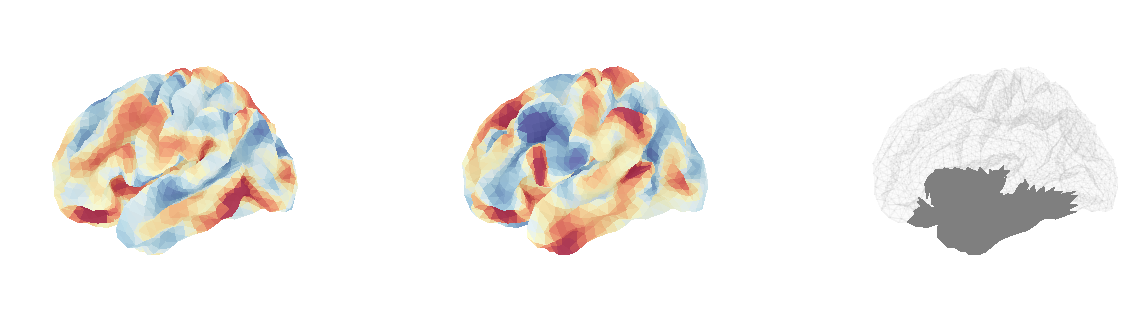

In [2]:
# plot example brain maps
acorr = acorrs[-1]
patch_size = patch_sizes[-1]
rng = np.random.default_rng()
patch = _subsample_vertices(adj_matrix, n_iterations=patch_size, seed=0)

X = rng.multivariate_normal(mean=[0, 0], cov=[[1, 0], [0, 1]], size=n_vertices)
X_smoothed = surface.smooth_surface_data(surface_mesh, X, iterations=acorr, match="dist")

fig, axs = plt.subplots(1, 3, figsize=(15, 4), subplot_kw=dict(projection="3d"))
plot_surf_kwargs = dict(bg_map=fsaverage.sulc_left, bg_on_data=True, cmap="RdYlBu", vmin=-2, vmax=2)
plotting.plot_surf(surface_mesh, X_smoothed[:, 0], axes=axs[0], **plot_surf_kwargs)
plotting.plot_surf(surface_mesh, X_smoothed[:, 1], axes=axs[1], **plot_surf_kwargs)
plotting.plot_surf_roi(surface_mesh, patch, axes=axs[2], alpha=0.02, cmap="binary")
pass

Text(0.5, 0, '$\\hat\\rho$')

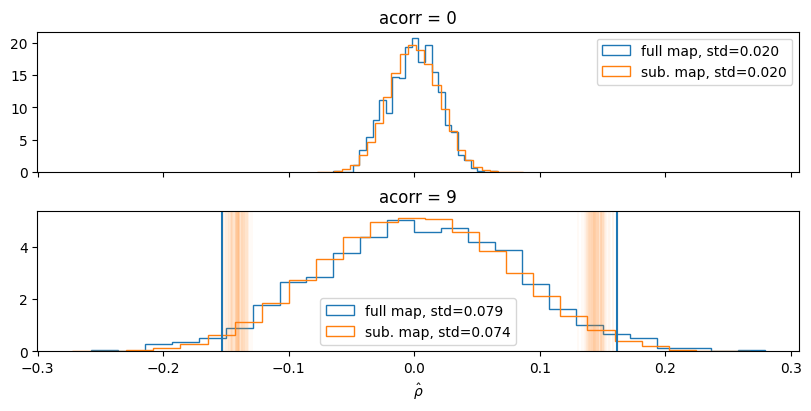

In [3]:
@delayed
def run_simulation(repeat):
    rng = np.random.default_rng(seed=repeat)
    # generate maps
    X = rng.multivariate_normal([0, 0], [[1, 0], [0, 1]], size=n_vertices)
    X_smoothed = surface.smooth_surface_data(surface_mesh, X, iterations=acorr, match="dist")

    # estimate cross-correlation
    xcorr_ = _xcorr(X[:, 0], X[:, 1])
    xcorr_sm_ = _xcorr(X_smoothed[:, 0], X_smoothed[:, 1])

    # bootstrap distribution
    xcorr_bs_, xcorr_bs_sm_ = np.zeros(n_subsamples), np.zeros(n_subsamples)
    for subsample in range(n_subsamples):
        patch = _subsample_vertices(adj_matrix, n_iterations=4, seed=(repeat + subsample))
        scale_std = np.sqrt(patch.sum() / n_vertices)
        xcorr_bs_[subsample] = _xcorr(X[patch, 0], X[patch, 1]) * scale_std
        patch = _subsample_vertices(adj_matrix, n_iterations=patch_size, seed=(repeat + subsample))
        scale_std = np.sqrt(patch.sum() / n_vertices)
        xcorr_bs_sm_[subsample] = _xcorr(X_smoothed[patch, 0], X_smoothed[patch, 1]) * scale_std

    return xcorr_, xcorr_sm_, xcorr_bs_, xcorr_bs_sm_


with Parallel(n_jobs=-2) as parallel:
    sim_results = parallel(run_simulation(repeat) for repeat in range(n_repeats))
    xcorr_, xcorr_sm_, xcorr_bs_, xcorr_bs_sm_ = map(np.asarray, zip(*sim_results))
    lwr = np.quantile(xcorr_sm_, alpha / 2)
    upr = np.quantile(xcorr_sm_, 1 - (alpha / 2))
    lwr_bs = np.quantile(xcorr_bs_sm_, alpha / 2, axis=0)
    upr_bs = np.quantile(xcorr_bs_sm_, 1 - (alpha / 2), axis=0)
    xcorr_bs_, xcorr_bs_sm_ = xcorr_bs_.flatten(), xcorr_bs_sm_.flatten()  # flatten over repeats

fig, axs = plt.subplots(nrows=2, figsize=(8, 4), sharex=True, layout="constrained")
hist_kwargs = dict(histtype="step", bins=25, density=True)
axs[0].set_title("acorr = 0")
axs[0].hist(xcorr_, **hist_kwargs, label=f"full map, std={xcorr_.std():.3f}")
axs[0].hist(xcorr_bs_, **hist_kwargs, label=f"sub. map, std={xcorr_bs_.std():.3f}")
axs[0].legend()
axs[1].set_title(f"acorr = {acorr}")
axs[1].hist(xcorr_sm_, **hist_kwargs, label=f"full map, std={xcorr_sm_.std():.3f}")
axs[1].hist(xcorr_bs_sm_, **hist_kwargs, label=f"sub. map, std={xcorr_bs_sm_.std():.3f}")
[axs[1].axvline(lw, lw=0.05, c="C1") for lw in lwr_bs]
[axs[1].axvline(up, lw=0.05, c="C1") for up in upr_bs]
axs[1].axvline(lwr, c="C0")
axs[1].axvline(upr, c="C0")
axs[1].legend()
axs[1].set_xlabel(r"$\hat\rho$")

**Empirical Quantiles Test**

In [4]:
@delayed
def run_simulation(acorr, repeat, n_vertices, n_subsamples, adj_matrix, patch_size, alpha):
    """empirical quantile test"""
    rng = np.random.default_rng(seed=repeat)

    # generate rho=0 map pairs
    X = rng.multivariate_normal(mean=[0, 0], cov=[[1, 0], [0, 1]], size=n_vertices)
    X_smoothed = surface.smooth_surface_data(surface_mesh, X, iterations=acorr, match="dist")

    # estimate cross-correlation
    xcorr_ = _xcorr(X_smoothed[:, 0], X_smoothed[:, 1])

    # bootstrap distribution
    xcorr_bs_ = np.zeros(n_subsamples)
    for subsample in range(n_subsamples):
        patch = _subsample_vertices(adj_matrix, n_iterations=patch_size, seed=(repeat + subsample))
        scale_std = np.sqrt(patch.sum() / n_vertices)
        xcorr_bs_[subsample] = _xcorr(X_smoothed[patch, 0], X_smoothed[patch, 1]) * scale_std

    # xcorr_bs_ -= xcorr_bs_.mean()
    lwr = np.quantile(xcorr_bs_, alpha / 2)
    upr = np.quantile(xcorr_bs_, 1 - (alpha / 2))

    return xcorr_ < lwr or xcorr_ > upr


for acorr, patch_size in zip(acorrs, patch_sizes):

    with Parallel(n_jobs=-2) as parallel:
        sim_results = parallel(
            run_simulation(acorr, repeat, n_vertices, n_subsamples, adj_matrix, patch_size, alpha)
            for repeat in range(n_repeats)
        )
        fpr = np.mean(sim_results)

    print(
        f"autocorrelation={acorr}",
        f"fpr={fpr}",
        sep="\t\t",
    )

autocorrelation=0		fpr=0.028
autocorrelation=1		fpr=0.041
autocorrelation=2		fpr=0.046
autocorrelation=3		fpr=0.051
autocorrelation=4		fpr=0.046
autocorrelation=5		fpr=0.047
autocorrelation=6		fpr=0.05
autocorrelation=7		fpr=0.048
autocorrelation=8		fpr=0.046
autocorrelation=9		fpr=0.04


**Modified f-Test**

$\left|\frac{\hat\rho\sqrt{\widehat{M}-2}}{\sqrt{1-\hat\rho^2}}\right|>t_{1-\alpha/2}(\widehat{M}-2)$  

or

$(\widehat{M}-2)\frac{\hat\rho^2}{1-\hat\rho^2} > F_{1-\alpha}(1,\widehat{M}-2)$

$\widehat M=1+(\widehat{\mathrm{var}}[\hat\rho])^{-1}$

In [5]:
@delayed
def run_simulation(acorr, repeat, n_vertices, n_subsamples, adj_matrix, patch_iter, alpha):
    """f-test accounting for effective sample size by subsampling"""

    rng = np.random.default_rng(seed=repeat)

    # generate rho=0 map pairs
    X = rng.multivariate_normal(mean=[0, 0], cov=[[1, 0], [0, 1]], size=n_vertices)
    X_smoothed = surface.smooth_surface_data(surface_mesh, X, iterations=acorr, match="dist")

    # estimate cross-correlation
    xcorr_ = _xcorr(X_smoothed[:, 0], X_smoothed[:, 1])

    # estimate effective sample size
    xcorr_ss_ = np.zeros(n_subsamples)
    for subsample in range(n_subsamples):
        patch = _subsample_vertices(adj_matrix, n_iterations=patch_iter, seed=(repeat + subsample))
        scale_std = np.sqrt(patch.sum() / n_vertices)
        xcorr_ss_[subsample] = _xcorr(X_smoothed[patch, 0], X_smoothed[patch, 1]) * scale_std
    m_ = 1 + (1 / xcorr_ss_.var())

    # f-tests
    f_naive_ = (n_vertices - 2) * ((xcorr_**2) / (1 - xcorr_**2))
    f_naive_dist = stats.f(1, (n_vertices - 2))
    f_ = (m_ - 2) * ((xcorr_**2) / (1 - xcorr_**2))
    f_dist = stats.f(1, (m_ - 2))

    return m_, f_naive_ > f_naive_dist.ppf((1 - alpha)), f_ > f_dist.ppf((1 - alpha))


for acorr, patch_size in zip(acorrs, patch_sizes):

    with Parallel(n_jobs=-2) as parallel:
        sim_results = parallel(
            run_simulation(acorr, repeat, n_vertices, n_subsamples, adj_matrix, patch_size, alpha)
            for repeat in range(n_repeats)
        )
        sim_results = np.mean(sim_results, axis=0)

    print(
        f"autocorrelation={acorr}",
        f"effective sample size={sim_results[0]:.2f}",
        f"fpr naive={sim_results[1]}",
        f"fpr adjusted={sim_results[2]}",
        sep="\t\t",
    )

autocorrelation=0		effective sample size=2723.79		fpr naive=0.041		fpr adjusted=0.051
autocorrelation=1		effective sample size=1811.39		fpr naive=0.136		fpr adjusted=0.072
autocorrelation=2		effective sample size=974.90		fpr naive=0.296		fpr adjusted=0.085
autocorrelation=3		effective sample size=658.23		fpr naive=0.412		fpr adjusted=0.1
autocorrelation=4		effective sample size=509.61		fpr naive=0.467		fpr adjusted=0.115
autocorrelation=5		effective sample size=424.14		fpr naive=0.513		fpr adjusted=0.122
autocorrelation=6		effective sample size=370.50		fpr naive=0.555		fpr adjusted=0.121
autocorrelation=7		effective sample size=334.28		fpr naive=0.587		fpr adjusted=0.126
autocorrelation=8		effective sample size=308.00		fpr naive=0.613		fpr adjusted=0.126
autocorrelation=9		effective sample size=289.30		fpr naive=0.632		fpr adjusted=0.146
